**Superstore Sales Data Analysis**

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import pandas as pd 
df = pd.read_csv("Sample - Superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df = df.drop_duplicates()

In [4]:
df.shape

(9994, 21)

**Highest Selling Category**

In [6]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

**Total business sales**

In [3]:
df['Sales'].sum()

np.float64(2297200.8603000003)

**Best top 5 selling products**

In [20]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

**Each region contributes to total sales in percentage**

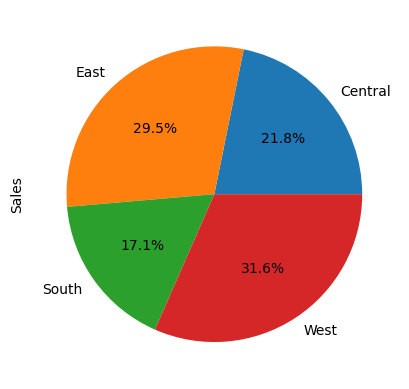

In [5]:
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')

plt.show()

**Save Cleaned Dataset**

In [6]:
df.to_csv("cleaned_superstore.csv", index=False)

**Most Profitable Category**

In [7]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

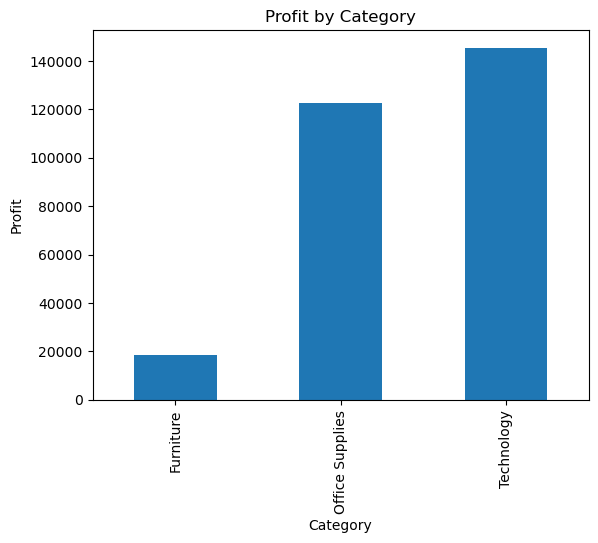

In [22]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

**Highest Sales Region**

In [9]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

**Highest Profit State**

In [10]:
df.groupby('State')['Profit'].sum().sort_values(ascending=False).head()

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Name: Profit, dtype: float64

**Loss-Making States**

In [11]:
df.groupby('State')['Profit'].sum().sort_values().head()

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Name: Profit, dtype: float64

**Monthly Sales Trend**

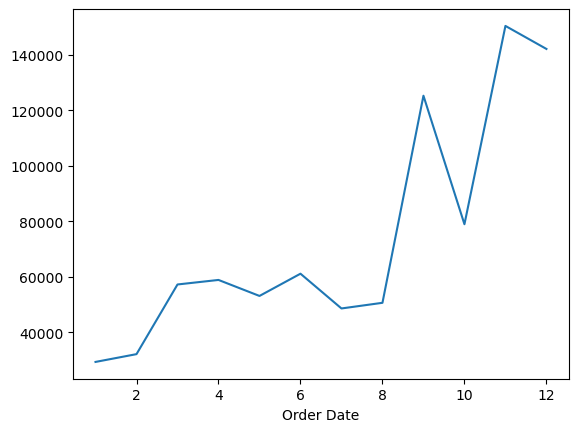

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

monthly_sales.plot(kind='line')

plt.show()

 **Business Insights**

In [ ]:
- Technology category generated highest sales
- West region contributed maximum revenue
- Monthly sales showed fluctuations over time
- Some states had lower profit compared to others

**SQL ANALYSIS**

In [1]:
import sqlite3

In [2]:
conn = sqlite3.connect('superstore.db')

In [5]:
df.to_sql('superstore', conn, if_exists='replace', index=False)

9994

**Category-wise Total Sales using SQL**

In [6]:
query = """
SELECT Category, SUM(Sales) as Total_Sales
FROM superstore
GROUP BY Category
"""

result = pd.read_sql(query, conn)

result

,Category,Total_Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


**Region-wise Total Sales using SQL**

In [7]:
query = """
SELECT Region, SUM(Sales) as Total_Sales
FROM superstore
GROUP BY Region
"""

pd.read_sql(query, conn)

,Region,Total_Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


**Top 5 Products by Sales using SQL**

In [8]:
query = """
SELECT `Product Name`, SUM(Sales) as Total_Sales
FROM superstore
GROUP BY `Product Name`
ORDER BY Total_Sales DESC
LIMIT 5
"""

pd.read_sql(query, conn)

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479


**Total Profit by Category Using Sql**

In [9]:
query = """
SELECT Category, SUM(Profit) as Total_Profit
FROM superstore
GROUP BY Category
"""

pd.read_sql(query, conn)

,Category,Total_Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481
